<h1>Import Libraries</h1>

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')
 
# Text & features
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
 
# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC          # optional swap for LR
 
# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.preprocessing import LabelEncoder
 
# Neural network (scikit-learn's MLP — no PyTorch needed for this baseline)
from sklearn.neural_network import MLPClassifier
 
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
 
print("All imports OK")

All imports OK


<h1>Load Data</h1>

Train and test sets are loaded from the shared split prepared in data_splitting.ipynb using a stratified 80/20 split with random_state=42 for reproducibility.

In [3]:
train_df = pd.read_csv('../data/train_data.csv')
test_df  = pd.read_csv('../data/test_data.csv')

TEXT_COL = "narrative"
LABEL_COL = "product"

print(f"Train: {train_df.shape} | Test: {test_df.shape}")


Train: (115169, 2) | Test: (28793, 2)


<h1>Label Encode</h1>

String labels are encoded to integers using LabelEncoder, fitted exclusively on training data to prevent leakage.

In [ ]:
le = LabelEncoder()
le.fit(train_df[LABEL_COL])   # fit on train only

y_train = le.transform(train_df[LABEL_COL].values)
y_test  = le.transform(test_df[LABEL_COL].values)

print("Classes:", le.classes_)

Classes: ['credit_card' 'credit_reporting' 'debt_collection' 'mortgages_and_loans'
 'retail_banking']


<h1>TF-IDF</h1>

Complaint narratives are vectorised using TF-IDF with unigram and bigram features, as specified in the project proposal. The vectoriser is fitted on training data only

In [5]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_features=50_000,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(train_df[TEXT_COL].values)  # fit on train only
X_test  = tfidf.transform(test_df[TEXT_COL].values)       # transform test

print(f"Feature matrix: {X_train.shape}")
# e.g. (115169, 50000) — 115k complaints, 50k features

Feature matrix: (115169, 50000)


<h1>Naive Bayes</h1>

Multinomial Naive Bayes is used as a probabilistic baseline, appropriate for TF-IDF features which are non-negative. Laplace smoothing (alpha=0.1) is applied to handle unseen terms

In [6]:
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("NAIVE BAYES")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))
print(f"Macro F1: {f1_score(y_test, y_pred_nb, average='macro'):.4f}")

NAIVE BAYES
                     precision    recall  f1-score   support

        credit_card       0.73      0.79      0.76      3439
   credit_reporting       0.89      0.83      0.86     12665
    debt_collection       0.80      0.74      0.77      5064
mortgages_and_loans       0.78      0.89      0.83      4402
     retail_banking       0.83      0.90      0.87      3223

           accuracy                           0.83     28793
          macro avg       0.81      0.83      0.82     28793
       weighted avg       0.83      0.83      0.83     28793

Macro F1: 0.8167


<h1>Logistic Regression</h1>

Logistic Regression with multinomial objective serves as a linear discriminative classifier. L2 regularisation (C=5.0) is applied to prevent overfitting on the high-dimensional TF-IDF feature space.

In [7]:
lr = LogisticRegression(
    C=5.0,
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))
print(f"Macro F1: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

LOGISTIC REGRESSION
                     precision    recall  f1-score   support

        credit_card       0.83      0.80      0.82      3439
   credit_reporting       0.89      0.91      0.90     12665
    debt_collection       0.83      0.79      0.81      5064
mortgages_and_loans       0.87      0.85      0.86      4402
     retail_banking       0.88      0.90      0.89      3223

           accuracy                           0.87     28793
          macro avg       0.86      0.85      0.86     28793
       weighted avg       0.87      0.87      0.87     28793

Macro F1: 0.8556


<h1>Neural Network</h1>

In [9]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=5,                # hard cap — we've seen it peaks at iter 1
    n_iter_no_change=2,        # stop after 2 iterations of no improvement
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("NEURAL NETWORK")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))
print(f"Macro F1: {f1_score(y_test, y_pred_mlp, average='macro'):.4f}")

Iteration 1, loss = 0.56465601
Validation score: 0.864809
Iteration 2, loss = 0.27415698
Validation score: 0.860814
Iteration 3, loss = 0.17251478
Validation score: 0.855171
Iteration 4, loss = 0.10639425
Validation score: 0.849874
Validation score did not improve more than tol=0.000100 for 2 consecutive epochs. Stopping.
NEURAL NETWORK
                     precision    recall  f1-score   support

        credit_card       0.82      0.81      0.81      3439
   credit_reporting       0.88      0.91      0.89     12665
    debt_collection       0.82      0.80      0.81      5064
mortgages_and_loans       0.88      0.84      0.86      4402
     retail_banking       0.88      0.90      0.89      3223

           accuracy                           0.86     28793
          macro avg       0.86      0.85      0.85     28793
       weighted avg       0.86      0.86      0.86     28793

Macro F1: 0.8537


<h1>Compare and Evaluate all 3 Models</h1>

Models are compared and evaluated using Macro F1-score, which weights all five classes equally regardless of size, addressing the class imbalance identified in the proposal.

In [10]:
results = {
    "Naive Bayes":          f1_score(y_test, y_pred_nb,  average='macro'),
    "Logistic Regression":  f1_score(y_test, y_pred_lr,  average='macro'),
    "Neural Network":       f1_score(y_test, y_pred_mlp, average='macro'),
}

print("\nModel Comparison — Macro F1")
print("-" * 40)
for model, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {model:<25} {score:.4f}")


Model Comparison — Macro F1
----------------------------------------
  Logistic Regression       0.8556
  Neural Network            0.8537
  Naive Bayes               0.8167


Row-normalised confusion matrices are plotted for each model to visualise per-class classification performance and identify systematic misclassification patterns.

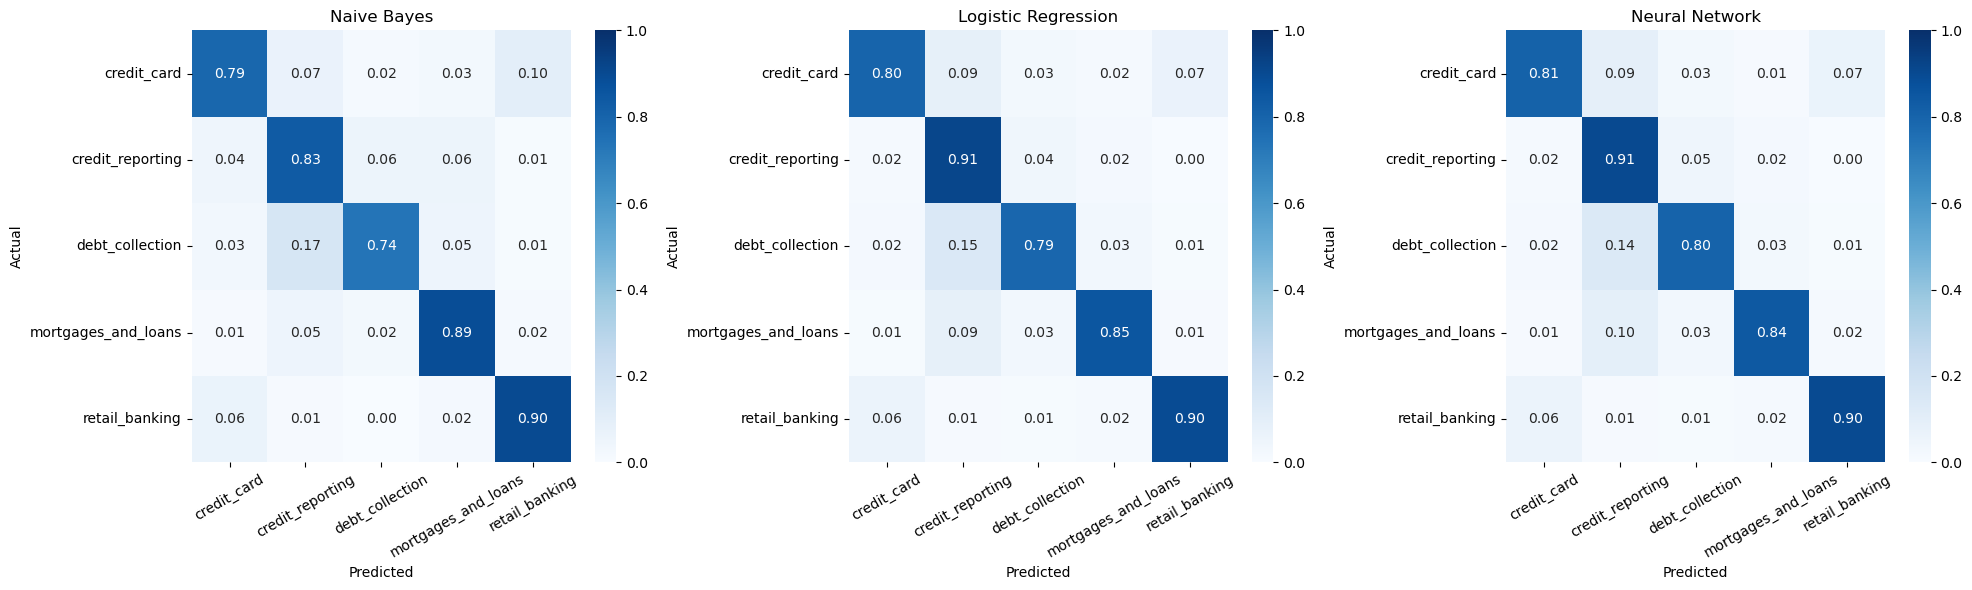

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
all_preds  = [y_pred_nb,  y_pred_lr,  y_pred_mlp]
all_titles = ["Naive Bayes", "Logistic Regression", "Neural Network"]

for ax, pred, title in zip(axes, all_preds, all_titles):
    cm = confusion_matrix(y_test, pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

<h1>Pick the best model</h1>

The best-performing model and its associated preprocessing objects are serialised using pickle for deployment in the interactive demo.

In [12]:
best_name  = max(results, key=results.get)
best_model = {"Naive Bayes": nb,
              "Logistic Regression": lr,
              "Neural Network": mlp}[best_name]

print(f"Best model: {best_name} ({results[best_name]:.4f})")

with open('../outputs/best_classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('../outputs/tfidf_vectoriser.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('../outputs/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Saved to outputs/")

Best model: Logistic Regression (0.8556)
Saved to outputs/
